In [5]:
import numpy as np
import pandas as pd
from pylab import plt, mpl
from sklearn.metrics import accuracy_score, f1_score
import os
import talib as ta
import optuna
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight

frequency = "1d"
window_pred = 7

# Cargar los datos para esta frecuencia
BTCUSDT = pd.read_csv('BTCUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
AVAXUSDT = pd.read_csv('AVAXUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
XRPUSDT = pd.read_csv('XRPUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
data = pd.DataFrame() 

data['BTCUSDT'] = BTCUSDT[['close']]
data['AVAXUSDT'] = AVAXUSDT[['close']]
data['XRPUSDT'] = XRPUSDT[['close']]
data.index = pd.to_datetime(data.index)
data.head()

,BTCUSDT,AVAXUSDT,XRPUSDT
timestamp,,,
2017-08-17,4285.08,NaN,NaN
2017-08-18,4108.37,NaN,NaN
2017-08-19,4139.98,NaN,NaN
2017-08-20,4086.29,NaN,NaN
2017-08-21,4016.00,NaN,NaN


In [6]:
data[data.isna().any(axis=1) & (data.index > pd.to_datetime('2020-09-22'))].index

DatetimeIndex([], dtype='datetime64[ns]', name='timestamp', freq=None)

Función para guardar los datos. Hace un archivo por cada frecuencia. Guarda en cada línea el modelo que se ha empleado, el activo, accuracy e in/out-sample.

In [7]:
def save_results(model, ric, acc, sample, frequency=frequency):
    # Verificar si el archivo ya existe
    file_name = f'accuracy_results_{frequency}_charac.csv'

    # Si el archivo existe, leer los datos previos, si no, crear un nuevo DataFrame vacío
    if os.path.exists(file_name):
        df_results = pd.read_csv(file_name)
    else:
        df_results = pd.DataFrame(columns=['Model', 'Asset', 'Accuracy', 'What'])

    # Agregar la nueva fila con los resultados
    new_row = pd.DataFrame([[model, ric, acc, sample]], columns=['Model', 'Asset', 'Accuracy', 'What'])
    df_results = pd.concat([df_results, new_row], ignore_index=True)

    # Guardar los resultados acumulados
    df_results.to_csv(file_name, index=False) 

Creamos las características que usaremos para hacer el aprendizaje ahora y las retardamos.

In [8]:
def charact_lags(data, ric, lags, window_pred, window=30):
    cols = []
    df = pd.DataFrame(data[ric])
    df['r'] = np.log(df / df.shift()) #retornos
    df['sma'] = df[ric].rolling(window).mean()  #media movil de la ventana
    df['min'] = df[ric].rolling(window).min() #mínimo de la ventana
    df['max'] = df[ric].rolling(window).max() #máximo de la ventana
    df['mom'] = df[ric].pct_change(window) #momentum de la ventana pct_change(12)
    df['vol'] = df['r'].rolling(window).std() #volatilidad de la ventana
    df['rsi'] = ta.RSI(df[ric], timeperiod=window) #rsi de la ventana
    df['atr'] = ta.ATR(df[ric], df[ric], df[ric], timeperiod=window) #atr de la ventana
    df = df.iloc[:-window_pred]
    df['d'] = np.where(df[ric].shift(-window_pred) > df[ric], 1, 0) # columna binaria, 0 si los precios bajarán, 1 si subirán
    features = [ric, 'r', 'sma', 'min', 'max', 'mom', 'vol', 'rsi', 'atr']
    for f in features:
        for lag in range(1, lags + 1):
            col = f'{f}_lag_{lag}'
            df[col] = df[f].shift(lag)
            cols.append(col)
    return df, cols

lags = 5

dfs = {}
results = []
for ric in data:
    df, cols = charact_lags(data, ric, lags, window_pred)
    dfs[ric] = df, cols
    p = df['d'].value_counts(normalize=True) 
    results.append({
        'ric': ric,
        '0': p[0], 
        '1': p[1]}
        )
results_df = pd.DataFrame(results)
results_df 

,ric,0,1
0,BTCUSDT,0.463542,0.536458
1,AVAXUSDT,0.718750,0.281250
2,XRPUSDT,0.574405,0.425595


Comentar que he mirado si los datos están desbalanceados 

In [47]:
dfs

{'BTCUSDT': (             BTCUSDT         r           sma       min        max       mom  \
  timestamp                                                                     
  2017-08-17   4285.08       NaN           NaN       NaN        NaN       NaN   
  2017-08-18   4108.37 -0.042113           NaN       NaN        NaN       NaN   
  2017-08-19   4139.98  0.007665           NaN       NaN        NaN       NaN   
  2017-08-20   4086.29 -0.013053           NaN       NaN        NaN       NaN   
  2017-08-21   4016.00 -0.017351           NaN       NaN        NaN       NaN   
  ...              ...       ...           ...       ...        ...       ...   
  2024-12-21  97291.99 -0.005264  98572.275000  91965.16  106133.74 -0.010427   
  2024-12-22  95186.27 -0.021881  98448.750667  91965.16  106133.74 -0.037472   
  2024-12-23  94881.47 -0.003207  98355.719667  91965.16  106133.74 -0.028574   
  2024-12-24  98663.58  0.039087  98381.171000  91965.16  106133.74  0.007799   
  2024-12-25  994

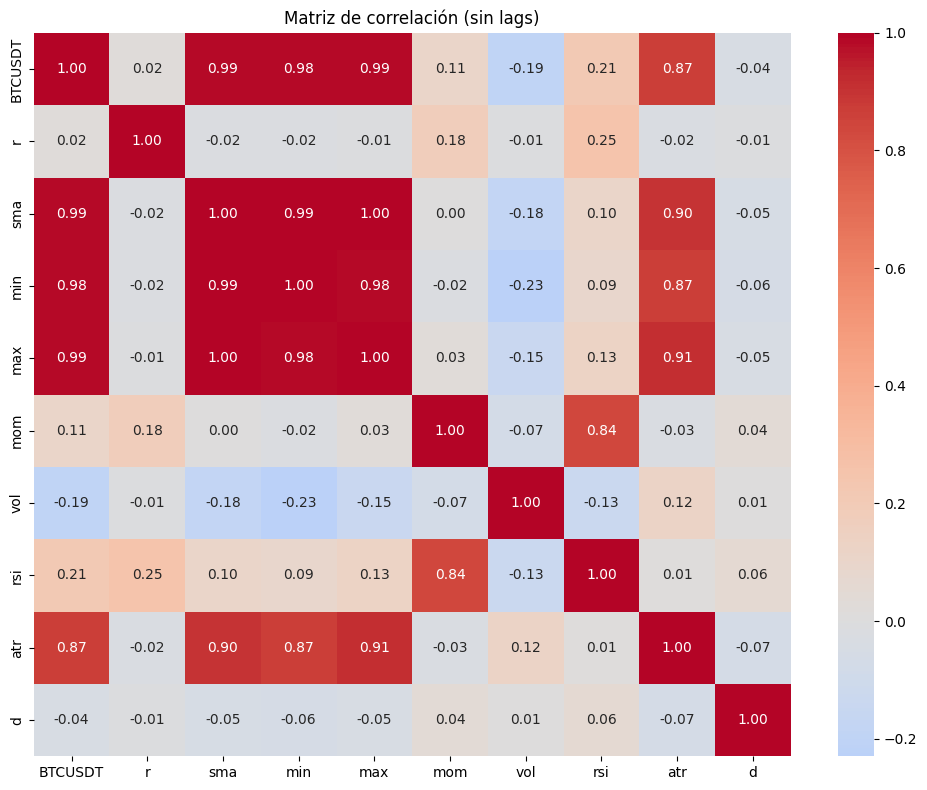

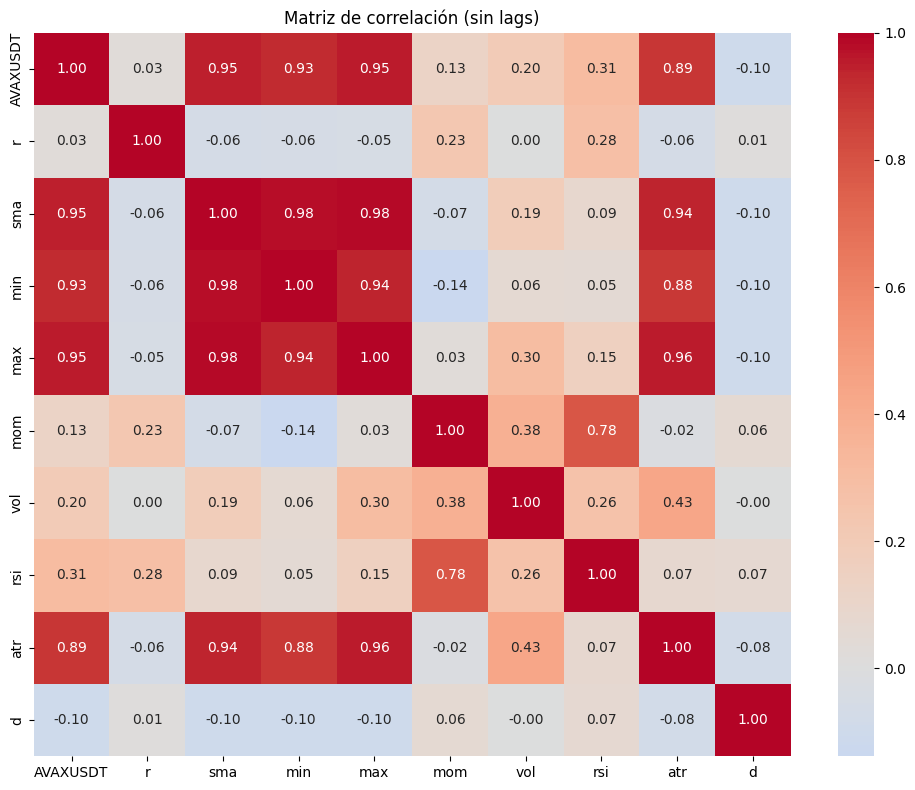

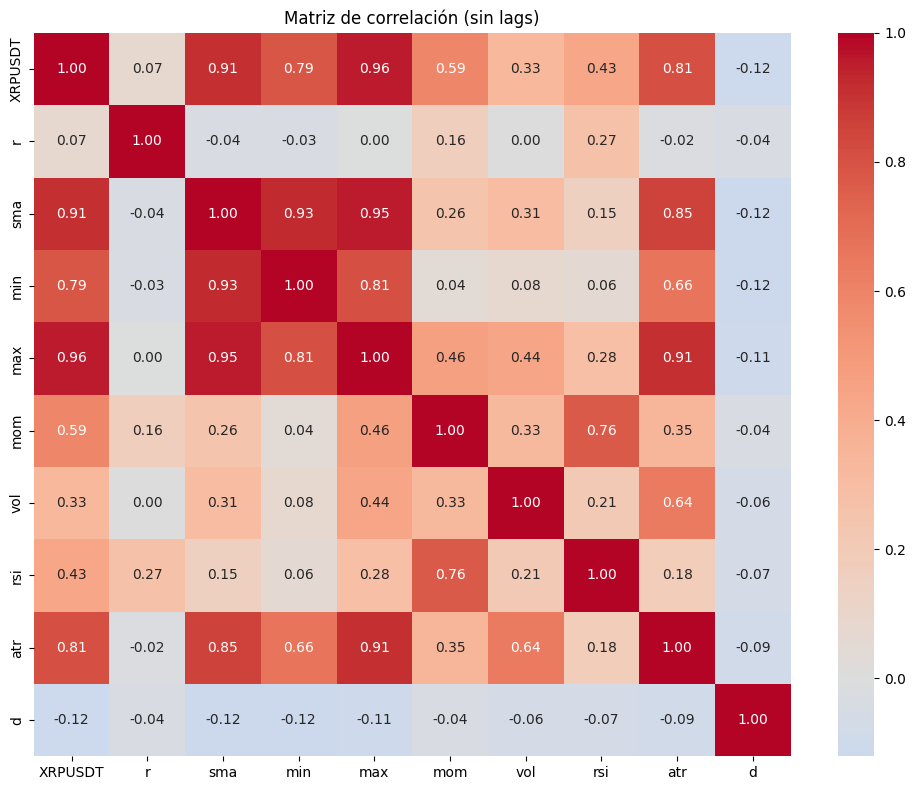

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

for ric in data:
    df, cols = dfs[ric]
    # Filtrar columnas que NO contienen 'lag' ni son no numéricas
    df_corr = df.drop(columns=[col for col in df.columns if 'lag' in col])

    # Calcular matriz de correlación
    corr_matrix = df_corr.corr()

    # Mostrar heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", center=0)
    plt.title("Matriz de correlación (sin lags)")
    plt.tight_layout()
    plt.show()

In [49]:
dfs[ric][0].columns

Index(['XRPUSDT', 'r', 'sma', 'min', 'max', 'mom', 'vol', 'rsi', 'atr', 'd',
       'XRPUSDT_lag_1', 'XRPUSDT_lag_2', 'XRPUSDT_lag_3', 'XRPUSDT_lag_4',
       'XRPUSDT_lag_5', 'r_lag_1', 'r_lag_2', 'r_lag_3', 'r_lag_4', 'r_lag_5',
       'sma_lag_1', 'sma_lag_2', 'sma_lag_3', 'sma_lag_4', 'sma_lag_5',
       'min_lag_1', 'min_lag_2', 'min_lag_3', 'min_lag_4', 'min_lag_5',
       'max_lag_1', 'max_lag_2', 'max_lag_3', 'max_lag_4', 'max_lag_5',
       'mom_lag_1', 'mom_lag_2', 'mom_lag_3', 'mom_lag_4', 'mom_lag_5',
       'vol_lag_1', 'vol_lag_2', 'vol_lag_3', 'vol_lag_4', 'vol_lag_5',
       'rsi_lag_1', 'rsi_lag_2', 'rsi_lag_3', 'rsi_lag_4', 'rsi_lag_5',
       'atr_lag_1', 'atr_lag_2', 'atr_lag_3', 'atr_lag_4', 'atr_lag_5'],
      dtype='object')

In [8]:
# Prueba a entrenar sin la columna d_lag_n para ver la importancia que tiene
'''
X_train = train.drop(columns=['d', 'timestamp'] + [col for col in train.columns if col.startswith('d_lag_')])
y_train = train['d']
X_test = test.drop(columns=['d', 'timestamp'] + [col for col in test.columns if col.startswith('d_lag_')])
y_test = test['d']
'''

"\nX_train = train.drop(columns=['d', 'timestamp'] + [col for col in train.columns if col.startswith('d_lag_')])\ny_train = train['d']\nX_test = test.drop(columns=['d', 'timestamp'] + [col for col in test.columns if col.startswith('d_lag_')])\ny_test = test['d']\n"

Modelo MLP Classifier

En esta versión de la función se usa una ventana de 90 días usando las fechas de los índices.

In [ ]:
'''
def walk_forward_fit_test(model_class, freq, model_params={}, n_trials=50):
    # Definir el período de test basado en la frecuencia
    if freq == '1h': total_period = pd.Timedelta(days=7)
    elif freq == '4h': total_period = pd.Timedelta(days=15)
    else: total_period = pd.Timedelta(days=90)
    test_period = total_period * 0.3   # 30% de los días
    train_period = total_period - test_period  # 63 días de entrenamiento
    
    def objective(trial):
        trial_params = {
            "hidden_layer_sizes": (trial.suggest_int("hidden_units", 32, 1024, step=64),),
            "alpha": trial.suggest_loguniform("alpha", 1e-5, 1e-1),
            "learning_rate_init": trial.suggest_loguniform("learning_rate", 1e-4, 1e-1),
            "max_iter": model_params.get("max_iter", 1000),
            "early_stopping": model_params.get("early_stopping", True),
            "validation_fraction": model_params.get("validation_fraction", 0.15),
            "shuffle": model_params.get("shuffle", False),
            "random_state": model_params.get("random_state", 100),
        }
        
        results = []
        for ric in data:
            df, cols = dfs[ric]
            df = df[cols + ['d']]
            df['timestamp'] = pd.to_datetime(df.index)
            
            max_time = df['timestamp'].max()
            min_time = df['timestamp'].min() + total_period
            split_dates = []
            current_time = min_time
            while current_time < max_time:
                split_dates.append(current_time)
                current_time += total_period  # Avance progresivo con total period
            
            for split_date in split_dates:
                train = df[(df['timestamp'] >= split_date - train_period) & (df['timestamp'] < split_date)]
                test = df[(df['timestamp'] >= split_date) & (df['timestamp'] < split_date + test_period)]
                
                if len(test) == 0:
                    continue  # Evitar iteraciones con test vacío
                
                X_train, y_train = train.drop(columns=['d', 'timestamp']), train['d']
                X_test, y_test = test.drop(columns=['d', 'timestamp']), test['d']
                
                # Normalizar usando solo datos de entrenamiento
                mean, std = X_train.mean(), X_train.std()
                std.replace(0, 1, inplace=True)
                X_train = (X_train - mean) / std
                X_test = (X_test - mean) / std
                
                # Crear y entrenar el modelo
                model = model_class(**trial_params)
                model.fit(X_train, y_train)
                
                # Predicción y evaluación
                pred = np.where(model.predict(X_test) > 0.5, 1, 0)
                acc = accuracy_score(y_test, pred)
                results.append(acc)
        
        avg_acc = np.mean(results) if results else 0  # Optuna maximiza esta métrica
        print(f'OUT-OF-SAMPLE | {ric:7s} | acc={avg_acc:.4f}')
        return avg_acc
    
    # Optimización con Optuna
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)
    
    print("Mejores parámetros encontrados:", study.best_params)
    return study.best_params'''

'import optuna\nfrom sklearn.model_selection import TimeSeriesSplit\nfrom sklearn.metrics import accuracy_score\n\ndef walk_forward_fit_test(model_class, freq, model_params={}, n_trials=50):\n    # Definir el período de test basado en la frecuencia\n    if freq == \'1h\': total_period = pd.Timedelta(days=7)\n    elif freq == \'4h\': total_period = pd.Timedelta(days=15)\n    else: total_period = pd.Timedelta(days=90)\n    test_period = total_period * 0.3   # 30% de los días\n    train_period = total_period - test_period  # 63 días de entrenamiento\n\n    def objective(trial):\n        trial_params = {\n            "hidden_layer_sizes": (trial.suggest_int("hidden_units", 32, 1024, step=64),),\n            "alpha": trial.suggest_loguniform("alpha", 1e-5, 1e-1),\n            "learning_rate_init": trial.suggest_loguniform("learning_rate", 1e-4, 1e-1),\n            "max_iter": model_params.get("max_iter", 1000),\n            "early_stopping": model_params.get("early_stopping", True),\n      

Hace el walk-forwark añadiendo ventanas (period) que seconvierten en la parte de test y todo lo anterior es train. (SIN AÑO DE TEST FINAL)

In [ ]:
'''
def walk_forward_fit_test(model_class, freq, model_params={}, n_trials=5): 
    # Definir el período de test basado en la frecuencia
    if freq == '1h': period = pd.Timedelta(days=7)
    elif freq == '4h': period = pd.Timedelta(days=15)
    else: period = pd.Timedelta(days=90)
    
    def objective(trial):
        trial_params = {
            "hidden_layer_sizes": (trial.suggest_int("hidden_units", 32, 1024, step=64),),
            "alpha": trial.suggest_loguniform("alpha", 1e-5, 1e-1),
            "learning_rate_init": trial.suggest_loguniform("learning_rate", 1e-4, 1e-1),
            "max_iter": model_params.get("max_iter", 1000),
            "early_stopping": model_params.get("early_stopping", True),
            "validation_fraction": model_params.get("validation_fraction", 0.15),
            "shuffle": model_params.get("shuffle", False),
            "random_state": model_params.get("random_state", 100),
        }
        
        results = []
        for ric in data:
            df, cols = dfs[ric]
            df = df[cols + ['d']]
            df['timestamp'] = pd.to_datetime(df.index)
            
            max_time = df['timestamp'].max()
            min_time = df['timestamp'].min()
            
            split_dates = []
            current_time = min_time + period
            while current_time < max_time:
                split_dates.append(current_time)
                current_time += period
            split_dates = split_dates[-5:]  # Elegimos solo los últimos 5 splits
            
            for split_date in split_dates:
                train = df[df['timestamp'] < split_date]
                test = df[(df['timestamp'] >= split_date) & (df['timestamp'] < split_date + period)]
                
                if len(test) == 0:
                    continue  # Evitar iteraciones con test vacío
                
                X_train, y_train = train.drop(columns=['d', 'timestamp']), train['d']
                X_test, y_test = test.drop(columns=['d', 'timestamp']), test['d']
                
                # Normalizar usando solo datos de entrenamiento
                mean, std = X_train.mean(), X_train.std()
                std.replace(0, 1, inplace=True)
                X_train = (X_train - mean) / std
                X_test = (X_test - mean) / std
                
                # Crear y entrenar el modelo
                model = model_class(**trial_params)
                model.fit(X_train, y_train)
                
                # Predicción y evaluación
                pred = np.where(model.predict(X_test) > 0.5, 1, 0)
                acc = accuracy_score(y_test, pred)
                results.append(acc)
        avg_acc = np.mean(results)  
        print(f'OUT-OF-SAMPLE | {ric:7s} | acc={avg_acc:.4f}')
        save_results(model_class.__name__, ric, avg_acc, "OUT-SAMPLE")
        return avg_acc # Optuna maximiza esta métrica
        
    
    # Optimización con Optuna
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)
    
    print("Mejores parámetros encontrados:", study.best_params)
    return study.best_params'''

'\ndef walk_forward_fit_test(model_class, freq, model_params={}, n_trials=5): \n    # Definir el período de test basado en la frecuencia\n    if freq == \'1h\': period = pd.Timedelta(days=7)\n    elif freq == \'4h\': period = pd.Timedelta(days=15)\n    else: period = pd.Timedelta(days=90)\n    \n    def objective(trial):\n        trial_params = {\n            "hidden_layer_sizes": (trial.suggest_int("hidden_units", 32, 1024, step=64),),\n            "alpha": trial.suggest_loguniform("alpha", 1e-5, 1e-1),\n            "learning_rate_init": trial.suggest_loguniform("learning_rate", 1e-4, 1e-1),\n            "max_iter": model_params.get("max_iter", 1000),\n            "early_stopping": model_params.get("early_stopping", True),\n            "validation_fraction": model_params.get("validation_fraction", 0.15),\n            "shuffle": model_params.get("shuffle", False),\n            "random_state": model_params.get("random_state", 100),\n        }\n        \n        results = []\n        for

In [ ]:
def walk_forward_fit_test(model_class, freq, model_params={}, n_trials=5):
    if freq == '1h':
        period = pd.Timedelta(days=7)
    elif freq == '4h':
        period = pd.Timedelta(days=15)
    else: period = pd.Timedelta(days=90)
    final_test_period = pd.Timedelta(days=365)

    def objective(trial):
        trial_params = {
            "hidden_layer_sizes": (trial.suggest_int("hidden_units", 32, 1024, step=64),),
            "alpha": trial.suggest_loguniform("alpha", 1e-5, 1e-1),
            "learning_rate_init": trial.suggest_loguniform("learning_rate", 1e-4, 1e-1),
            "max_iter": model_params.get("max_iter", 1000),
            "early_stopping": model_params.get("early_stopping", True),
            "validation_fraction": model_params.get("validation_fraction", 0.15),
            "shuffle": model_params.get("shuffle", False),
            "random_state": model_params.get("random_state", 100),
        }

        results = []
        for ric in data:
            df, cols = dfs[ric]
            df = df[cols + ['d']]
            df.dropna(inplace=True)
            df['timestamp'] = pd.to_datetime(df.index)
            max_time = df['timestamp'].max()
            cutoff = max_time - final_test_period  # Reservamos el último año
            df_trainval = df[df['timestamp'] < cutoff]

            # Walk-forward en datos previos al último año
            min_time = df_trainval['timestamp'].min()
            split_dates = []
            current_time = min_time + period
            while current_time < cutoff:
                split_dates.append(current_time)
                current_time += period
            split_dates = split_dates[-5:]

            for split_date in split_dates:
                train = df_trainval[df_trainval['timestamp'] < (split_date - pd.Timedelta(days=window_pred))]
                test = df_trainval[(df_trainval['timestamp'] >= split_date) & (df_trainval['timestamp'] < split_date + period)]
                #fin_train = split_date - pd.Timedelta(days=window_pred)
                #print('split_date, comienzo split', split_date)
                #fin_test= split_date + period
                #print('fin_train', fin_train - pd.Timedelta(days=window_pred))
                #print('fin_test', fin_test )
                #print('\n')

                if len(test) == 0:
                    continue

                X_train, y_train = train.drop(columns=['d', 'timestamp']), train['d']
                X_test, y_test = test.drop(columns=['d', 'timestamp']), test['d']

                mean, std = X_train.mean(), X_train.std()
                std.replace(0, 1, inplace=True)
                X_train = (X_train - mean) / std
                X_test = (X_test - mean) / std

                model = model_class(**trial_params)
                model.fit(X_train, y_train)

                # importancia de las características
                '''result = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=0)
                sorted_idx = result.importances_mean.argsort()[::-1]  # orden descendente
                print("Feature importances (top 10):")
                for i in sorted_idx[:10]:
                    print(f"{X_train.columns[i]:<30} - Importance: {result.importances_mean[i]:.4f}")'''

                pred = np.where(model.predict(X_test) > 0.5, 1, 0)
                acc = accuracy_score(y_test, pred)
                results.append(acc)

            avg_acc = np.mean(results)
            print(f'VALIDATION | {ric:7s} | acc={avg_acc:.4f}')
            #save_results(model_class.__name__, ric, avg_acc, "OUT-SAMPLE")
        return avg_acc

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)

    best_params = study.best_params
    print("Mejores parámetros encontrados:", best_params)

    # Entrenamiento final con mejor hiperparámetros, test en último año
    for ric in data:
        df, cols = dfs[ric]
        df = df[cols + ['d']]
        df.dropna(inplace=True)
        df['timestamp'] = pd.to_datetime(df.index)
        max_time = df['timestamp'].max()
        cutoff = max_time - final_test_period

        train = df[df['timestamp'] < (cutoff - pd.Timedelta(days=window_pred))]
        test = df[df['timestamp'] >= cutoff]
        

        if len(test) == 0:
            continue

        X_train, y_train = train.drop(columns=['d', 'timestamp']), train['d']
        X_test, y_test = test.drop(columns=['d', 'timestamp']), test['d']

        mean, std = X_train.mean(), X_train.std()
        std.replace(0, 1, inplace=True)
        X_train = (X_train - mean) / std
        X_test = (X_test - mean) / std

        model = model_class(
            hidden_layer_sizes=(best_params["hidden_units"],),
            alpha=best_params["alpha"],
            learning_rate_init=best_params["learning_rate"],
            max_iter=model_params.get("max_iter", 1000),
            early_stopping=model_params.get("early_stopping", True),
            validation_fraction=model_params.get("validation_fraction", 0.15),
            shuffle=model_params.get("shuffle", False),
            random_state=model_params.get("random_state", 100),
        )
        model.fit(X_train, y_train)
        # importancia de las características
        '''result = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=0)
        sorted_idx = result.importances_mean.argsort()[::-1]  # orden descendente
        print("Feature importances (top 10):")
        for i in sorted_idx[:10]:
            print(f"{X_train.columns[i]:<30} - Importance: {result.importances_mean[i]:.4f}")'''
            
        pred = np.where(model.predict(X_test) > 0.5, 1, 0)
        acc = accuracy_score(y_test, pred)
        print(f'FINAL TEST | {ric:7s} | acc={acc:.4f}')
        #save_results(model_class.__name__, ric, acc, "FINAL-TEST")

    return best_params


In [ ]:
      
# Ejecutar la optimización
model_params = {
    "max_iter": 1000,
    "early_stopping": True,
    "validation_fraction": 0.15,
    "shuffle": False,
    "random_state": 100
}

tuned_params = walk_forward_fit_test(MLPClassifier, frequency, model_params, n_trials=1)


[I 2025-06-03 18:30:45,017] A new study created in memory with name: no-name-6bc7248c-6cfb-45a7-bbc3-f8b5f4079c5c
C:\Users\raque\AppData\Roaming\Python\Python311\site-packages\optuna\distributions.py:699: UserWarning: The distribution is specified by [32, 1024] and step=64, but the range is not divisible by `step`. It will be replaced by [32, 992].
  warnings.warn(
C:\Users\raque\AppData\Local\Temp\ipykernel_39868\488392392.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "alpha": trial.suggest_loguniform("alpha", 1e-5, 1e-1),
C:\Users\raque\AppData\Local\Temp\ipykernel_39868\488392392.py:13: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "learning_rate_init": trial.

VALIDATION | BTCUSDT | acc=0.5383


C:\Users\raque\AppData\Local\Temp\ipykernel_39868\488392392.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)
C:\Users\raque\AppData\Local\Temp\ipykernel_39868\488392392.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['timestamp'] = pd.to_datetime(df.index)


VALIDATION | AVAXUSDT | acc=0.4916


C:\Users\raque\AppData\Local\Temp\ipykernel_39868\488392392.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)
C:\Users\raque\AppData\Local\Temp\ipykernel_39868\488392392.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['timestamp'] = pd.to_datetime(df.index)
[I 2025-06-03 18:30:52,252] Trial 0 finished with value: 0.4986262006687539 and parameters: {'hidden_units': 480, 'alpha': 0.011628520753166643, 'learning_rate': 0.00028045206963801204}. Best is trial 0 with value: 0.4986262006687539.


VALIDATION | XRPUSDT | acc=0.4986


KeyboardInterrupt: 

Versión con todos los modelos

In [9]:
def normalize_with_close(X, close_col):
    """
    Normaliza columnas ratio en función del precio de cierre.
    """
    ratio_cols = [col for col in X.columns if any(x in col for x in ['sma','atr','min','max'])]
    for col in ratio_cols:
        X[col] = X[col] / close_col
    return X

# ---------------------------------------------------
def prepare_features(df):
    """
    One-hot encoding de la columna 'crypto'.
    """
    crypto_dummies = pd.get_dummies(df['crypto'], prefix='crypto')
    X = pd.concat([df.drop(columns=['crypto']), crypto_dummies], axis=1)
    return X, crypto_dummies.columns

# ---------------------------------------------------

versión 03/06 añadiendo:
 - optuna con f1
 - imprimir f1 y guardar
 - nueva normalización
 - más modelos

In [12]:
def walk_forward_fit_test(model_class, freq, model_params={}, n_trials=5, search_space=None, data=data):
    if freq == '1h':
        period = pd.Timedelta(days=7)
    elif freq == '4h':
        period = pd.Timedelta(days=15)
    else:
        period = pd.Timedelta(days=90)
    final_test_period = pd.Timedelta(days=365)

    def suggest_params(trial):
        trial_params = {}
        for param_name, param_info in search_space.items():
            if param_info['type'] == 'int':
                trial_params[param_name] = trial.suggest_int(param_name, *param_info['bounds'])
            elif param_info['type'] == 'float':
                trial_params[param_name] = trial.suggest_float(param_name, *param_info['bounds'], log=param_info.get('log', False))
            elif param_info['type'] == 'categorical':
                trial_params[param_name] = trial.suggest_categorical(param_name, param_info['choices'])
        trial_params.update(model_params)
        return trial_params

    ric_best_params = {}
    desb_graf = []
    df_res = None

    for ric in data:
        df, cols = data[ric]
        df = df[cols + ['d']].copy()
        df.dropna(inplace=True)
        df['timestamp'] = pd.to_datetime(df.index)
        max_time = df['timestamp'].max()
        cutoff = max_time - final_test_period
        df_trainval = df[df['timestamp'] < cutoff].copy()

        # Generar fechas de split
        min_time = df_trainval['timestamp'].min()
        split_dates = []
        current_time = min_time + period
        while current_time < cutoff:
            split_dates.append(current_time)
            current_time += period
        split_dates = split_dates[-5:]

        def objective(trial):
            trial_params = suggest_params(trial)
            resul_acc = []
            resul_f1 = []

            for split_date in split_dates:
                train = df_trainval[df_trainval['timestamp'] < (split_date - pd.Timedelta(days=window_pred))]
                test = df_trainval[(df_trainval['timestamp'] >= split_date) & (df_trainval['timestamp'] < split_date + period)]
                if len(test) == 0:
                    continue

                X_train, y_train = train.drop(columns=['d', 'timestamp']), train['d']
                X_test, y_test = test.drop(columns=['d', 'timestamp']), test['d']
                X_train = normalize_with_close(X_train.copy(), train[f'{ric}_lag_1'])
                X_test = normalize_with_close(X_test.copy(), test[f'{ric}_lag_1'])

                model = model_class(**trial_params)
                if model_class.__name__ == 'MLPClassifier':
                    X_train = X_train.loc[:, ~X_train.columns.str.contains(ric)]
                    X_test = X_test.loc[:, ~X_test.columns.str.contains(ric)]
                    model.fit(X_train, y_train)
                else:
                    weights = compute_sample_weight(class_weight='balanced', y=y_train)
                    X_train = X_train.loc[:, ~X_train.columns.str.contains(ric)]
                    X_test = X_test.loc[:, ~X_test.columns.str.contains(ric)]
                    model.fit(X_train, y_train, sample_weight=weights)

                pred = np.where(model.predict(X_test) > 0.5, 1, 0)
                f1 = f1_score(y_test, pred, average='macro')
                acc = accuracy_score(y_test, pred)
                resul_acc.append(acc)
                resul_f1.append(f1)

            avg_f1 = np.mean(resul_f1)
            avg_acc = np.mean(resul_acc)
            dist_true = y_test.value_counts(normalize=True).to_dict()
            dist_pred = pd.Series(pred).value_counts(normalize=True).to_dict()
            print(f'VALIDATION |  {ric:7s} | avg_acc={avg_acc:.4f} | avg_f1={avg_f1:.4f}')
            save_results(model_class.__name__, ric, avg_f1, 'F1 VALIDATION', frequency=freq)
            print(f"    Desbalanceo reales (val)      : {dist_true}")
            print(f"    Desbalanceo predicciones (val): {dist_pred}")
            save_results(model_class.__name__, ric, dist_true, 'DESBALANCEO REAL VAL', frequency=freq)
            save_results(model_class.__name__, ric, dist_pred, 'DESBALANCEO PREDICCIÓN VAL', frequency=freq)
            return avg_f1

        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials, n_jobs=1)

        best_params = study.best_params
        ric_best_params[ric] = best_params
        print(f"Mejores parámetros para {ric}: {best_params}")

        # Test final con los mejores parámetros
        df_test = df[df['timestamp'] >= cutoff].copy()
        train = df[df['timestamp'] < (cutoff - pd.Timedelta(days=window_pred))]
        test = df_test

        if len(test) == 0:
            continue

        X_train, y_train = train.drop(columns=['d', 'timestamp']), train['d']
        X_test, y_test = test.drop(columns=['d', 'timestamp']), test['d']

        X_train = normalize_with_close(X_train.copy(), train[f'{ric}_lag_1'])
        X_test = normalize_with_close(X_test.copy(), test[f'{ric}_lag_1'])

        model = model_class(**best_params)
        if model_class.__name__ == 'MLPClassifier':
            X_train = X_train.loc[:, ~X_train.columns.str.contains(ric)]
            X_test = X_test.loc[:, ~X_test.columns.str.contains(ric)]
            model.fit(X_train, y_train)
        else:
            weights = compute_sample_weight(class_weight='balanced', y=y_train)
            X_train = X_train.loc[:, ~X_train.columns.str.contains(ric)]
            X_test = X_test.loc[:, ~X_test.columns.str.contains(ric)]
            model.fit(X_train, y_train, sample_weight=weights)

        pred = np.where(model.predict(X_test) > 0.5, 1, 0)
        df_res = pd.DataFrame({'true': y_test, 'pred': pred})
        acc = accuracy_score(y_test, pred)
        f1 = f1_score(y_test, pred, average='macro')
        dist_true = y_test.value_counts(normalize=True).to_dict()
        dist_pred = pd.Series(pred).value_counts(normalize=True).to_dict()
        real_0 = dist_true.get(0, 0)
        real_1 = dist_true.get(1, 0)
        pred_0 = dist_pred.get(0, 0)
        pred_1 = dist_pred.get(1, 0)

        desb_graf.append({
            "cripto": ric,
            "acc": acc,
            "f1": f1,
            "real_0": real_0,
            "real_1": real_1,
            "pred_0": pred_0,
            "pred_1": pred_1
        })
        print(f'FINAL TEST | {ric:7s} | acc={acc:.4f} | f1={f1:.4f}')
        print(f"    Desbalanceo reales      : {dist_true}")
        print(f"    Desbalanceo predicciones: {dist_pred}")
        save_results(model_class.__name__, ric, acc, 'FINAL TEST', frequency=freq)
        save_results(model_class.__name__, ric, f1, 'F1 FINAL TEST', frequency=freq)
        save_results(model_class.__name__, ric, dist_true, 'DESBALANCEO REAL', frequency=freq)
        save_results(model_class.__name__, ric, dist_pred, 'DESBALANCEO PREDICCIÓN', frequency=freq)

        if model_class.__name__ != 'MLPClassifier':
            df_weights = pd.DataFrame({'y': y_train, 'weight': weights})
            avg_weights = df_weights.groupby('y')['weight'].mean().to_dict()
            print(f"    Pesos promedio entrenamiento: {avg_weights}")

    return ric_best_params, desb_graf, df_res


In [ ]:
# === Definición del espacio de búsqueda para cada modelo ===

search_spaces = {
    "MLPClassifier": {
        "hidden_layer_sizes": {"type": "int",   "bounds": (32, 1024), "step": 32},
        "alpha":              {"type": "float", "bounds": (1e-6, 1e-1), "log": True},
        "learning_rate_init": {"type": "float", "bounds": (1e-5, 1e-1), "log": True},
    },
    "RandomForestClassifier": {
        "n_estimators":      {"type": "int",         "bounds": (100, 1000), "step": 100},
        "max_depth":         {"type": "int",         "bounds": (3,   30)},
        "min_samples_split": {"type": "int",         "bounds": (2,   10)},
        "min_samples_leaf":  {"type": "int",         "bounds": (1,   10)},
        "max_features":      {"type": "categorical", "choices": ["sqrt", "log2", None]},
        "bootstrap":         {"type": "categorical", "choices": [True, False]},
    },
    "SVC": {
        "C":     {"type": "float", "bounds": (1e-2, 1e3), "log": True},
        "gamma": {"type": "float", "bounds": (1e-5, 1e-1), "log": True},
        "kernel":{"type": "categorical", "choices": ["rbf", "poly", "sigmoid"]},
    },
    "GradientBoostingClassifier": {
        "n_estimators":      {"type": "int",   "bounds": (50, 500),  "step": 50},
        "learning_rate":     {"type": "float", "bounds": (1e-3, 0.3), "log": True},
        "max_depth":         {"type": "int",   "bounds": (3,   15)},
        "min_samples_split": {"type": "int",   "bounds": (2,   20)},
        "min_samples_leaf":  {"type": "int",   "bounds": (1,   20)},
    },
}

# === Parámetros fijos para cada modelo ===

model_fixed_params = {
    "MLPClassifier": {
        "max_iter": 1000,
        "early_stopping": True,
        "validation_fraction": 0.15,
        "shuffle": False,
        "random_state": 100,
    },
    "RandomForestClassifier": {
        "random_state": 100,
        "n_jobs": -1
    },
    "SVC": {
        "probability": True,
        "random_state": 100
    },
    "GradientBoostingClassifier": {
        "random_state": 100
    }
}

# === Diccionario de clases de modelos ===

model_classes = {
    "MLPClassifier": MLPClassifier,
    "RandomForestClassifier": RandomForestClassifier,
    "SVC": SVC,
    "GradientBoostingClassifier": GradientBoostingClassifier
}

# === Entrenamiento en bucle ===

best_params_dict = {}
desb_graf_dict = {}
data_graf_dict = {}

for model_name, model_cls in model_classes.items():
    print(f"\n\n=== Entrenando modelo: {model_name} ===\n")
    
    best_params, desb_graf, df_res = walk_forward_fit_test(
        model_class=model_cls,
        freq=frequency,
        search_space=search_spaces[model_name],
        model_params=model_fixed_params.get(model_name, {}),
        n_trials=1,
        data=dfs  
    )

    best_params_dict[model_name] = best_params
    desb_graf_dict[model_name] = desb_graf
    data_graf_dict[model_name] = df_res

print("\n\n=== Mejores hiperparámetros por modelo ===")
for model_name, params in best_params_dict.items():
    print(f"{model_name}: {params}")


[I 2025-06-11 23:41:14,816] A new study created in memory with name: no-name-a31167ff-dc13-4412-b7d1-47c41e56989f




=== Entrenando modelo: MLPClassifier ===



[I 2025-06-11 23:41:15,709] Trial 0 finished with value: 0.5043940938473351 and parameters: {'hidden_layer_sizes': 260, 'alpha': 1.1133545517471519e-06, 'learning_rate_init': 2.935639689930746e-05}. Best is trial 0 with value: 0.5043940938473351.


VALIDATION |  BTCUSDT | avg_acc=0.5514 | avg_f1=0.5044
    Desbalanceo reales (val)      : {1: 0.6486486486486487, 0: 0.35135135135135137}
    Desbalanceo predicciones (val): {1: 0.6756756756756757, 0: 0.32432432432432434}
Mejores parámetros para BTCUSDT: {'hidden_layer_sizes': 260, 'alpha': 1.1133545517471519e-06, 'learning_rate_init': 2.935639689930746e-05}


[I 2025-06-11 23:41:16,783] A new study created in memory with name: no-name-b2f49ecc-18c2-40f4-b6cb-2ee5fe846f78


...

FINAL TEST | BTCUSDT | acc=0.5683 | f1=0.5654
    Desbalanceo reales      : {1: 0.5628415300546448, 0: 0.4371584699453552}
    Desbalanceo predicciones: {0: 0.644808743169399, 1: 0.3551912568306011}
    Pesos promedio entrenamiento: {0: 1.073446327683616, 1: 0.9359605911330049}


[I 2025-06-11 23:41:29,301] Trial 0 finished with value: 0.4611767741664094 and parameters: {'n_estimators': 780, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.4611767741664094.


VALIDATION |  AVAXUSDT | avg_acc=0.5004 | avg_f1=0.4612
    Desbalanceo reales (val)      : {1: 0.84, 0: 0.16}
    Desbalanceo predicciones (val): {0: 0.52, 1: 0.48}
Mejores parámetros para AVAXUSDT: {'n_estimators': 780, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}


[I 2025-06-11 23:41:31,153] A new study created in memory with name: no-name-a64b023f-9142-440f-82b5-d51cd4d69953


FINAL TEST | AVAXUSDT | acc=0.5492 | f1=0.5151
    Desbalanceo reales      : {0: 0.5245901639344263, 1: 0.47540983606557374}
    Desbalanceo predicciones: {0: 0.7404371584699454, 1: 0.25956284153005466}
    Pesos promedio entrenamiento: {0: 0.9845626072041166, 1: 1.015929203539823}


C:\Users\raque\AppData\Local\Temp\ipykernel_44052\180652519.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(models))  # tab10 da 10 colores distintos


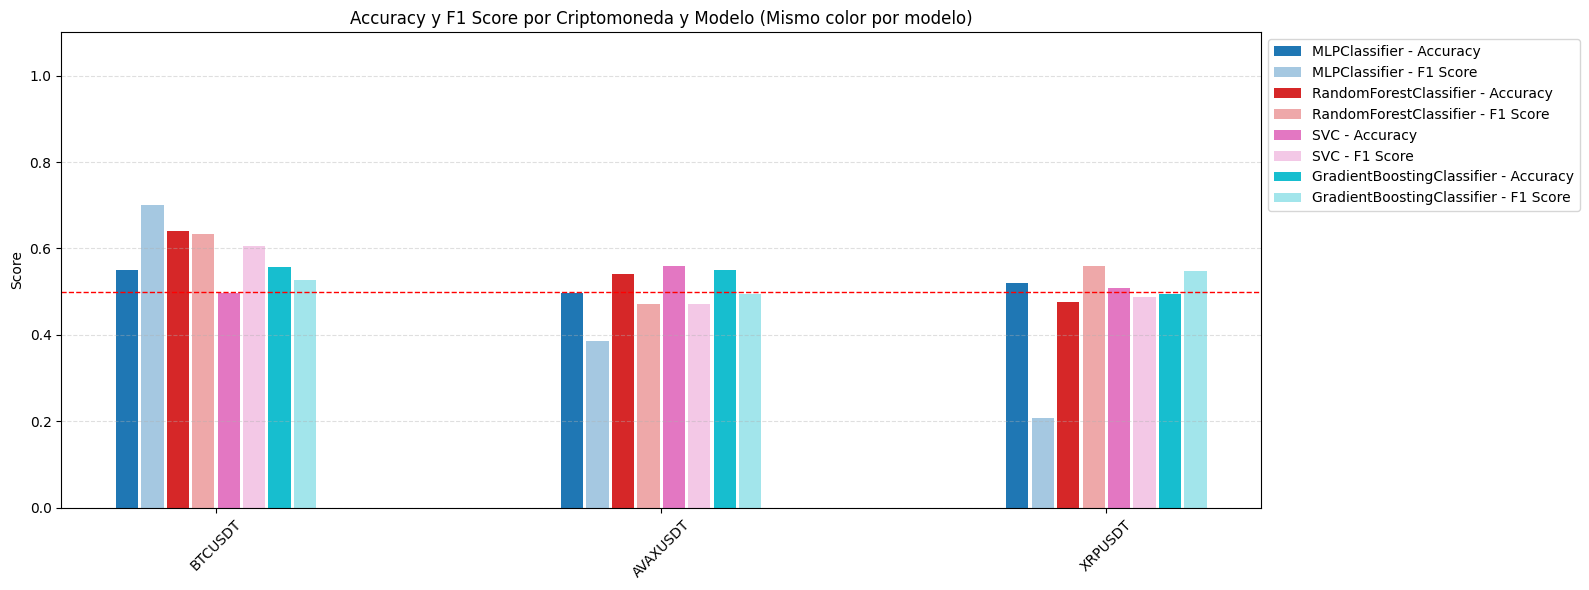

In [64]:
import matplotlib.cm as cm
df_all = []
for model_name, results in desb_graf_dict.items():
    df_model = pd.DataFrame(results) 
    df_model["model"] = model_name
    df_all.append(df_model)

df = pd.concat(df_all, ignore_index=True)

# Preparar gráfico
cryptos = df["cripto"].unique()
models = df["model"].unique()
metrics = ["acc", "f1"]

fig, ax = plt.subplots(figsize=(16, 6))
bar_width = 0.05
x = np.arange(len(cryptos))

# Paleta de colores base por modelo
colors = cm.get_cmap('tab10', len(models))  # tab10 da 10 colores distintos

# Calcular desplazamientos
total_bars = len(models) * len(metrics)
offsets = np.linspace(-bar_width * total_bars / 2, bar_width * total_bars / 2, total_bars)

for i, model in enumerate(models):
    color_base = colors(i)
    for j, metric in enumerate(metrics):
        values = df[df["model"] == model].set_index("cripto").loc[cryptos][metric]
        alpha = 1.0 if metric == "acc" else 0.4  # Misma base de color, más claro para F1
        label = f"{model} - {'Accuracy' if metric == 'acc' else 'F1 Score'}"
        position = x + offsets[i * len(metrics) + j]
        ax.bar(position, values, width=bar_width, label=label, color=color_base, alpha=alpha)

# Ejes
ax.set_xticks(x)
ax.set_xticklabels(cryptos, rotation=45)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("Accuracy y F1 Score por Criptomoneda y Modelo (Mismo color por modelo)")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Límite 0.5')
plt.tight_layout()
plt.show()


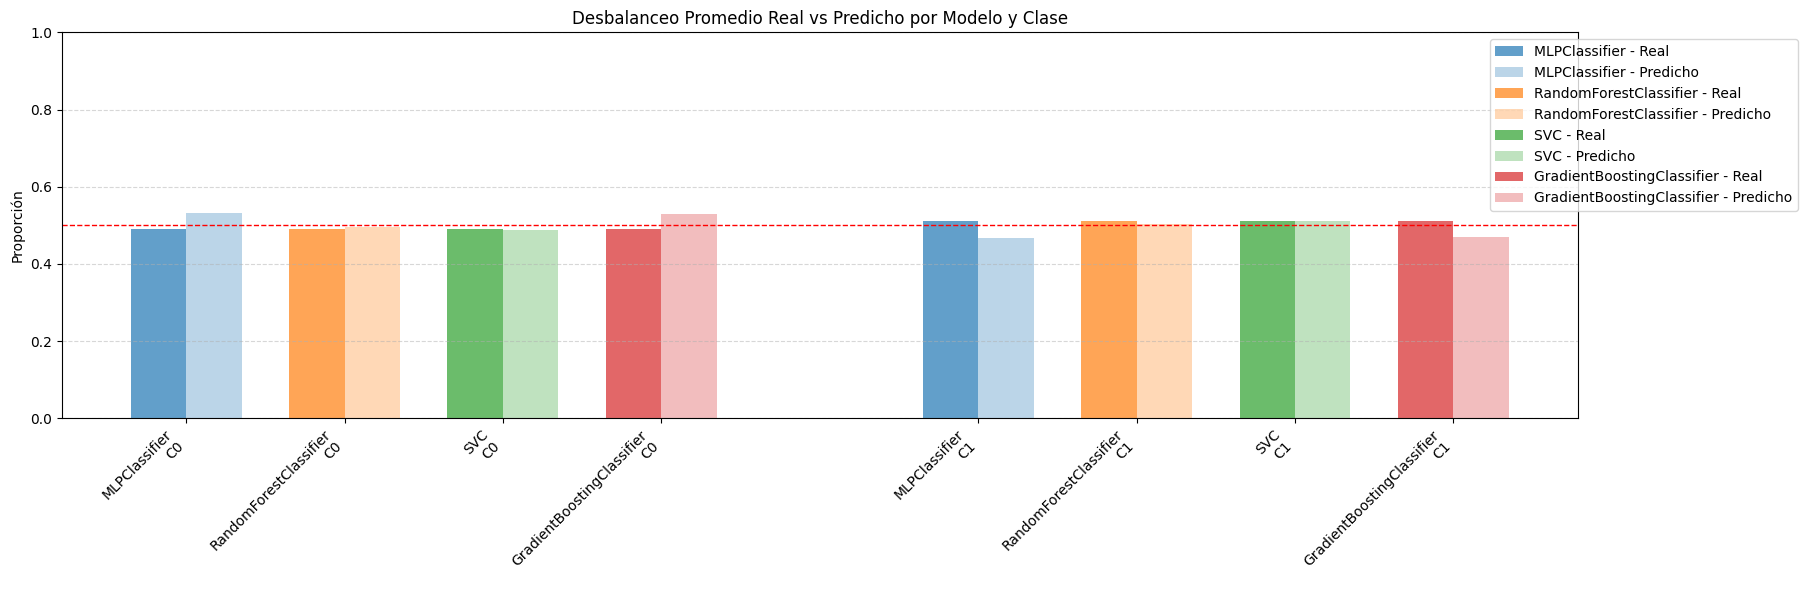

In [66]:
# Datos para el gráfico
model_names = list(desb_graf_dict.keys())
n_models = len(model_names)
bar_width = 0.35
spacing = 1.0  # espacio entre los grupos de clase 0 y clase 1

# Posiciones en el eje x
x_class_0 = np.arange(n_models)
x_class_1 = x_class_0 + n_models + spacing  # separado por un espacio

fig, ax = plt.subplots(figsize=(18, 6))

colors = plt.cm.tab10.colors  # paleta estándar de 10 colores

for idx, (model_name, data_graf) in enumerate(desb_graf_dict.items()):
    df = pd.DataFrame(data_graf)
    
    real_0 = df['real_0'].mean()
    pred_0 = df['pred_0'].mean()
    real_1 = df['real_1'].mean()
    pred_1 = df['pred_1'].mean()
    
    # barras clase 0
    ax.bar(x_class_0[idx], real_0, width=bar_width, label=f'{model_name} - Real', color=colors[idx], alpha=0.7)
    ax.bar(x_class_0[idx] + bar_width, pred_0, width=bar_width, label=f'{model_name} - Predicho', color=colors[idx], alpha=0.3)
    
    # barras clase 1
    ax.bar(x_class_1[idx], real_1, width=bar_width, color=colors[idx], alpha=0.7)
    ax.bar(x_class_1[idx] + bar_width, pred_1, width=bar_width, color=colors[idx], alpha=0.3)

# Etiquetas y ejes
ax.set_xticks(
    list(x_class_0 + bar_width / 2) + list(x_class_1 + bar_width / 2)
)
ax.set_xticklabels(
    [f'{name}\nC0' for name in model_names] + [f'{name}\nC1' for name in model_names],
    rotation=45, ha='right'
)
ax.set_ylabel('Proporción')
ax.set_title('Desbalanceo Promedio Real vs Predicho por Modelo y Clase')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Límite 0.5')
plt.tight_layout()
